# Figure 5 (paper style): Cubic queue occupancy vs. queue size

Recreates Figure 5 of the CCAnalyzer paper (5 Mbps, 275 ms, Cubic, queues of 32/128/512/1024 packets).

- Occupancy is divided by the buffer size (so 1.0 = full queue).
- Our qdisc sampler records every ~5 ms, which is much finer than the paper's figure. Measuring the
  bends in the paper's plotted lines puts its points about **0.5 s apart**, so we reduce to one point
  every `BIN_S` = 0.5 s.
- By default (`HOW = 'sample'`) each point is the **actual queue reading at that 0.5 s mark**, joined
  with straight lines. This keeps sharp drops and true peaks. `'mean'`, `'max'` and `'median'` instead
  summarize each 0.5 s window; `'mean'` looks noticeably smoother. The last cell compares all methods.
- Styling matches the paper: one colorblind-safe color per queue size, a shared legend on top,
  no grid or panel titles, and thick lines.

In [15]:
import sys, os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO = '/home/jaber/agentic-thin-waist'
RESULTS = os.path.join(REPO, 'cc_results')
# Fresh runs in cc_results/ shadow the July archive.
SEARCH_DIRS = [d for d in [RESULTS, '/home/jaber/atw_data_backup_20260716_174105/cc_results']
               if os.path.isdir(d)]
sys.path.insert(0, os.path.join(REPO, 'services', 'analysis'))
from queue_trace import load_queue_trace

# ---- knobs ----
CC, BW, RTT = 'cubic', 5, 275
QS = [32, 128, 512, 1024]
BIN_S = 0.5     # averaging window (s)
HOW = 'sample'  # 'sample' = reading at each tick; or 'mean' / 'max' / 'median' per window
TMAX = 60
PAPER_COLORS = ['#0173B2', '#DE8F05', '#029E73', '#D55E00']  # seaborn 'colorblind'

In [16]:
def find_trace(tag):
    for d in SEARCH_DIRS:
        cands = [p for p in glob.glob(os.path.join(d, tag + '__*'))
                 if (p.endswith('.jsonl') or 'queue' in os.path.basename(p).lower())
                 and os.path.getsize(p) > 0]
        if cands:
            return sorted(cands, key=os.path.getsize, reverse=True)[0]
    return None

def load_bottleneck(tag):
    # backlog series on the bottleneck iface (highest mean backlog)
    p = find_trace(tag)
    if not p:
        raise FileNotFoundError(f'no queue trace for {tag}')
    df = load_queue_trace(p)
    iface = df.groupby('iface')['backlog_pkts'].mean().idxmax()
    return df[df['iface'] == iface].sort_values('rel_t').reset_index(drop=True)

def bin_occupancy(sub, qcap, bin_s=None, tmax=TMAX, how=None):
    # reduce the ~5 ms trace to one point per bin_s -> (times, occupancy / qcap)
    bin_s = BIN_S if bin_s is None else bin_s
    how = HOW if how is None else how
    s = sub[sub['backlog_pkts'].notna() & (sub['rel_t'] <= tmax)]
    if how == 'sample':
        # queue reading at each tick (linear interp between the two nearest samples)
        grid = np.arange(0, tmax + 1e-9, bin_s)
        y = np.interp(grid, s['rel_t'].values, s['backlog_pkts'].values)
        return grid, np.clip(y / qcap, None, 1.0)
    b = (s['rel_t'] // bin_s).astype(int)
    agg = s.groupby(b)['backlog_pkts'].agg(how)
    return (agg.index + 0.5) * bin_s, (agg / qcap).clip(upper=1.0)

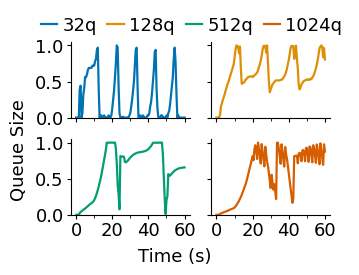

In [17]:
# Figure 5 style = same config as the WD/CDF plot (intra_inter_cdf.pdf):
# Helvetica, 3.5 in SIGCOMM column width, golden-ratio height, 16 pt labels/ticks,
# 12 pt legend, 0.5 pt axes, 2 pt lines, grid on.
import matplotlib as mpl
import matplotlib.font_manager as fm

HELVETICA = '/home/jaber/helvetica-255/Helvetica.ttf'
if os.path.exists(HELVETICA):
    fm.fontManager.addfont(HELVETICA)
    FIG5_FAMILY = fm.FontProperties(fname=HELVETICA).get_name()
else:  # metric-compatible Helvetica clone; copy Helvetica.ttf here and rerun to use the real one
    FIG5_FAMILY = 'Liberation Sans'
print('Figure 5 font:', FIG5_FAMILY)

def golden_ratio_figsize(width, fraction=1.0):
    return (width, width / ((1 + 5 ** 0.5) / 2) * fraction)

FIG5_SIZE = golden_ratio_figsize(3.5)   # (3.5, 2.16) in, same as the WD plot
FIG5_LW = 2
style = {
    'font.family': FIG5_FAMILY,
    'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 12,
    'axes.linewidth': 0.5, 'grid.linewidth': 0.5,
    'axes.grid': True,
    'xtick.major.pad': 2, 'ytick.major.pad': 2,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
}

def plot_fig5(tag_of_q, out_paths):
    with plt.rc_context(style):
        fig, axes = plt.subplots(2, 2, figsize=FIG5_SIZE, sharex=True, sharey=True)
        handles = []
        for ax, q, col in zip(axes.flat, QS, PAPER_COLORS):
            t, y = bin_occupancy(load_bottleneck(tag_of_q(q)), q)
            handles += ax.plot(t, y, color=col, lw=FIG5_LW, label=f'{q}q')
            ax.set_ylim(0, 1.08); ax.set_yticks([0, 1])
            ax.set_xlim(0, TMAX); ax.set_xticks([0, 30, 60])
        fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
                   bbox_to_anchor=(0.55, 0.97), handlelength=1.2,
                   columnspacing=0.8, handletextpad=0.3, borderaxespad=0)
        fig.supylabel('Queue Size', x=0.0, fontsize=16)
        fig.supxlabel('Time (s)', y=0.0, fontsize=16)
        fig.tight_layout(pad=0.2, h_pad=0.3, w_pad=0.5)
        for path in out_paths:
            fig.savefig(path, bbox_inches='tight', pad_inches=0.02)
        plt.show()

plot_fig5(lambda q: f'{CC}_{BW}bw-{RTT}rtt-{q}q',
          [os.path.join(RESULTS, f'fig_paper05_{CC}_queue_sweep_paperstyle.png')])

## Comparing reduction methods

Same four traces under each method, from the raw 5 ms data (A) down. The method changes the look only
a little; most of the remaining difference from the paper's Figure 5 is in the runs themselves.
For example, the paper's 32q panel shows paired spikes over a non-zero floor, while ours drains to 0
between single peaks.

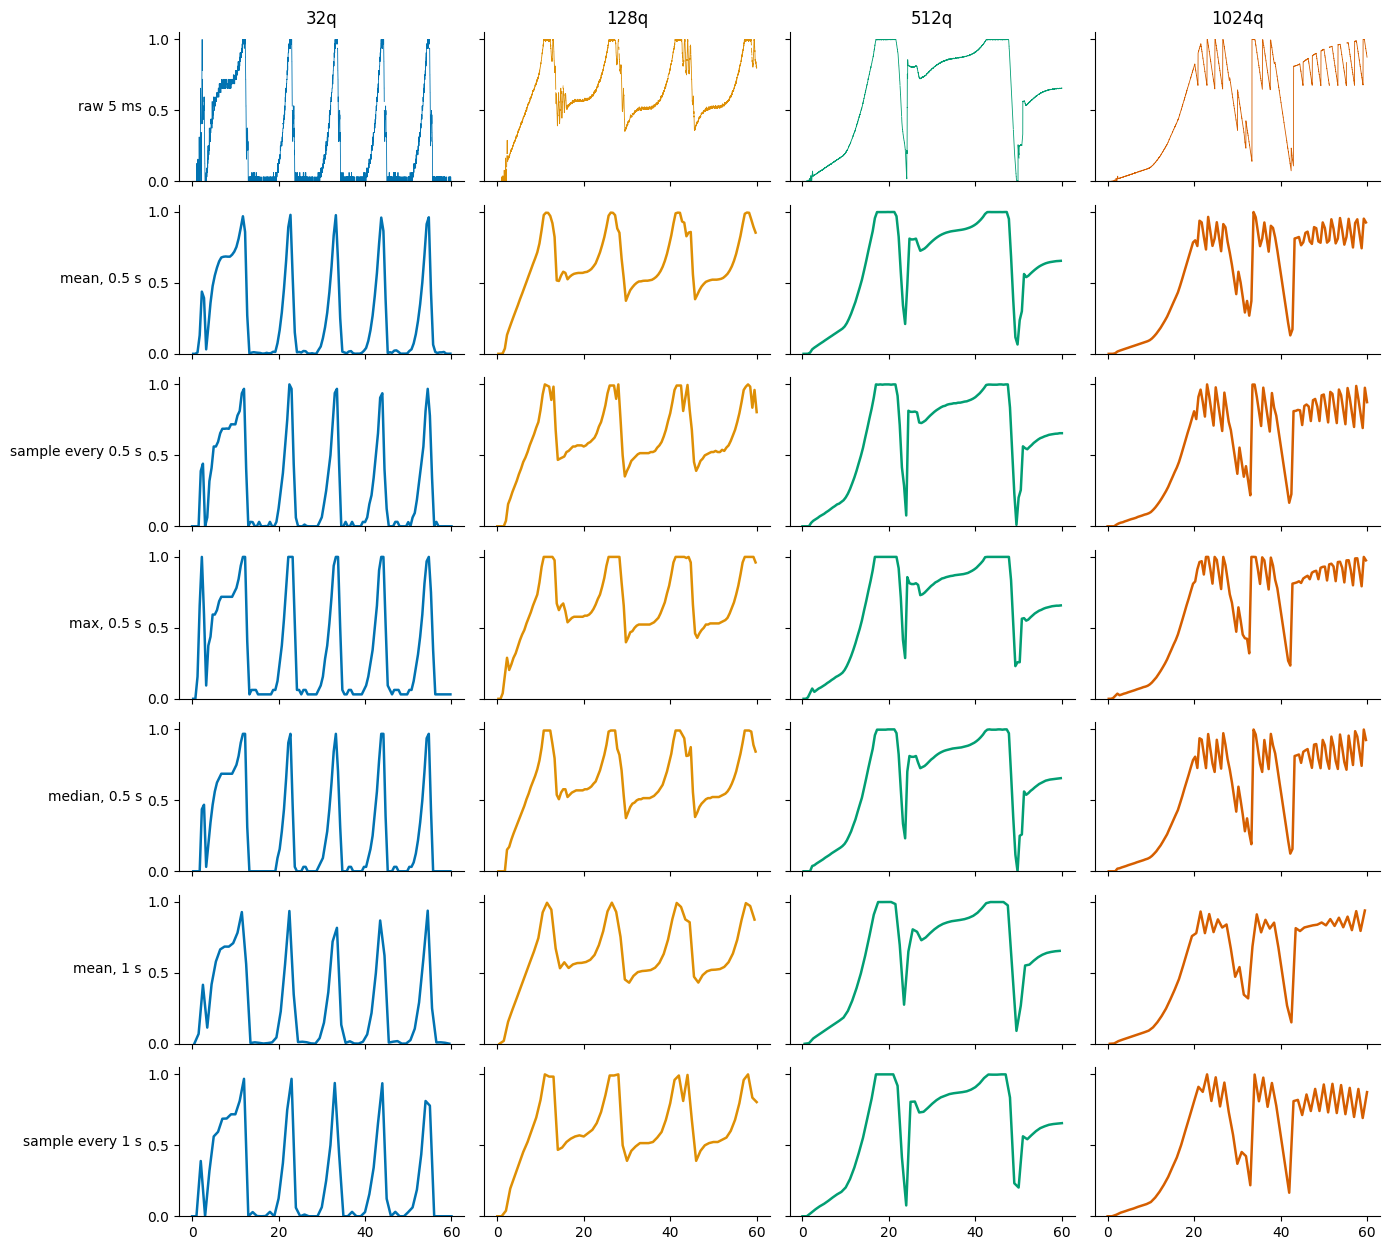

In [18]:
METHODS = [('raw', None, 'raw 5 ms'), ('mean', 0.5, 'mean, 0.5 s'),
           ('sample', 0.5, 'sample every 0.5 s'), ('max', 0.5, 'max, 0.5 s'),
           ('median', 0.5, 'median, 0.5 s'), ('mean', 1.0, 'mean, 1 s'),
           ('sample', 1.0, 'sample every 1 s')]
traces = {q: load_bottleneck(f'{CC}_{BW}bw-{RTT}rtt-{q}q') for q in QS}

fig, axes = plt.subplots(len(METHODS), len(QS), figsize=(14, 1.8 * len(METHODS)),
                         sharex=True, sharey=True)
for r, (how, w, lab) in enumerate(METHODS):
    for c, (q, col) in enumerate(zip(QS, PAPER_COLORS)):
        ax = axes[r, c]
        if how == 'raw':
            s = traces[q][traces[q]['rel_t'] <= TMAX]
            ax.plot(s['rel_t'], s['backlog_pkts'] / q, color=col, lw=0.6)
        else:
            t, y = bin_occupancy(traces[q], q, bin_s=w, how=how)
            ax.plot(t, y, color=col, lw=1.8)
        ax.set_ylim(0, 1.05); ax.set_yticks([0, 0.5, 1.0]); ax.set_xticks([0, 20, 40, 60])
        ax.spines[['top', 'right']].set_visible(False); ax.grid(False)
        if r == 0: ax.set_title(f'{q}q')
        if c == 0: ax.set_ylabel(lab, rotation=0, ha='right', va='center')
fig.tight_layout()
plt.show()

## Figure 5 re-run: packet merging off, large TCP buffers

Collected with `sudo bash run_cc_fig5_nooffload.sh` (tags `cubic_5bw-275rtt-<Q>q-nooffload`). Same local wget of `1GB.bin`,
but with TSO/GSO/GRO off on every hop, `tcp_min_tso_segs=1` on the sender, sender `tcp_wmem` max 32 MB, and client (ns1)
`tcp_rmem` max 32 MB. The queue now holds MTU-sized packets (~1500 B, as in the paper's BESS switch) instead of
~2900 B merged ones, and the receive window no longer caps the 1024q run. Settings used are logged in
`cc_results/fig5_nooffload_settings.txt`.

In [19]:
SUFFIX = 'nooffload'
NEW = lambda q: f'{CC}_{BW}bw-{RTT}rtt-{q}q-{SUFFIX}'

# sanity check: queued bytes per packet (old runs ~2900 B, new should be ~1500 B)
for q in QS:
    for lab, tag in [('old', f'{CC}_{BW}bw-{RTT}rtt-{q}q'), ('new', NEW(q))]:
        try:
            s = load_bottleneck(tag)
        except FileNotFoundError:
            print(f'{q:>5}q {lab}: missing'); continue
        nz = s[s['backlog_pkts'] > 0]
        print(f"{q:>5}q {lab}: {nz['backlog_bytes'].sum() / nz['backlog_pkts'].sum():6.0f} B/pkt, "
              f"mean occupancy {s['backlog_pkts'].mean() / q:.2f}, drops {int(s['drops'].max())}")

   32q old:   2843 B/pkt, mean occupancy 0.26, drops 54
   32q new:   1514 B/pkt, mean occupancy 0.34, drops 57
  128q old:   2778 B/pkt, mean occupancy 0.62, drops 205
  128q new:   1514 B/pkt, mean occupancy 0.67, drops 112
  512q old:   2852 B/pkt, mean occupancy 0.63, drops 518
  512q new:   1514 B/pkt, mean occupancy 0.71, drops 351
 1024q old:   2954 B/pkt, mean occupancy 0.57, drops 63
 1024q new:   1514 B/pkt, mean occupancy 0.69, drops 873


In [ ]:
plot_fig5(NEW,
          [os.path.join(RESULTS, f'fig_paper05_{CC}_queue_sweep_paperstyle_{SUFFIX}.png'),
           os.path.join(RESULTS, f'fig5_{SUFFIX}.pdf'),
           'fig5.pdf'])

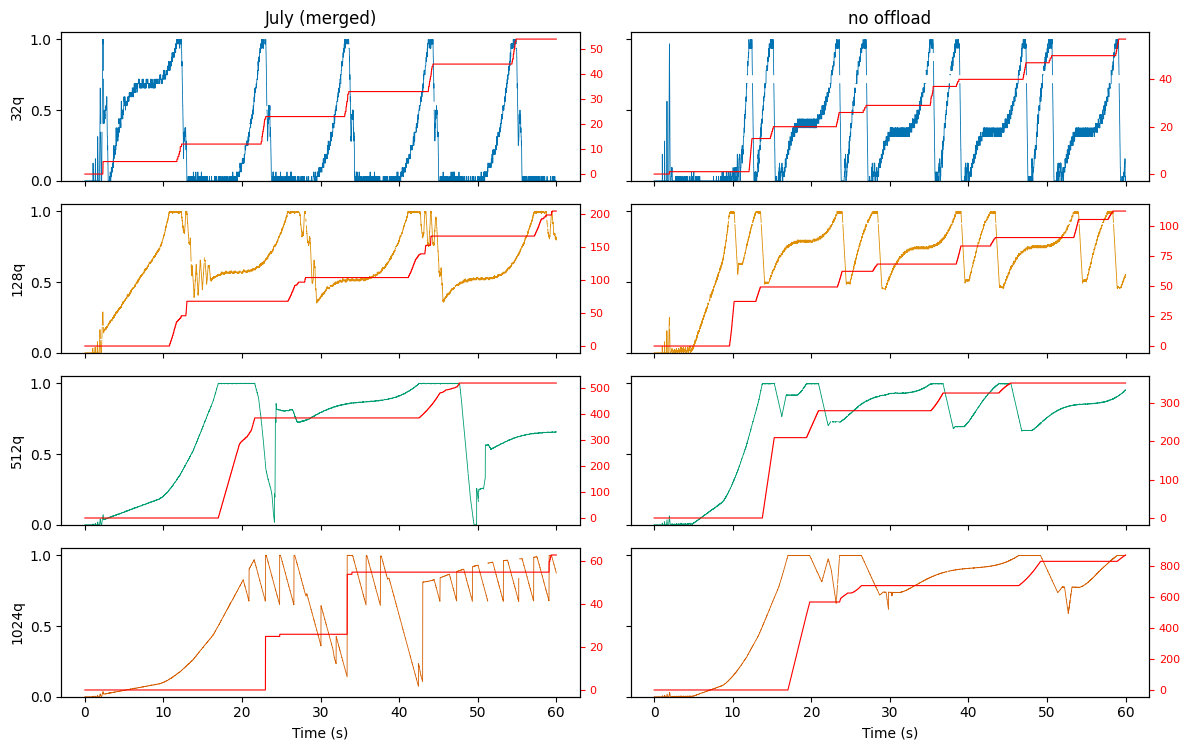

In [11]:
# old (merged packets, 3 MB rwnd cap) vs new, raw 5 ms traces, with cumulative drops in red
fig, axes = plt.subplots(len(QS), 2, figsize=(12, 1.9 * len(QS)), sharex=True, sharey=True)
for r, (q, col) in enumerate(zip(QS, PAPER_COLORS)):
    for c, (lab, tag) in enumerate([('July (merged)', f'{CC}_{BW}bw-{RTT}rtt-{q}q'),
                                    ('no offload', NEW(q))]):
        ax = axes[r, c]
        s = load_bottleneck(tag); s = s[s['rel_t'] <= TMAX]
        ax.plot(s['rel_t'], s['backlog_pkts'] / q, color=col, lw=0.6)
        ax2 = ax.twinx(); ax2.plot(s['rel_t'], s['drops'], color='red', lw=0.8)
        ax2.tick_params(labelsize=8, colors='red')
        ax.set_ylim(0, 1.05); ax.set_yticks([0, 0.5, 1.0])
        if r == 0: ax.set_title(lab)
        if c == 0: ax.set_ylabel(f'{q}q')
axes[-1, 0].set_xlabel('Time (s)'); axes[-1, 1].set_xlabel('Time (s)')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, f'fig_paper05_{CC}_old_vs_{SUFFIX}.png'), dpi=150, bbox_inches='tight')
plt.show()